In [1]:
import os
import re
import pandas as pd

# Replace this with your actual data directory
data_dir = r"EMGlabDatabaseWav\EMGlabDatabaseWav"
filenames = [f for f in os.listdir(data_dir) if f.startswith("N2001")]

def parse_filename(fname):
    """
    Parses EMGLab N2001 filenames like 'N2001A01BB02.wav'
    Returns subject ID, label, muscle, and recording ID
    """
    # Allow optional ".wav" at the end
    pattern = r"N2001([AMC])(\d+)([A-Z]{2})(\d+)(?:\.wav)?$"
    match = re.match(pattern, fname)
    if not match:
        return None

    label_code = match.group(1)
    subject_id = match.group(2)
    muscle = match.group(3)
    rec_id = int(match.group(4))

    label_map = {"A": "ALS", "M": "Myopathy", "C": "Normal"}

    return {
        "filename": fname,
        "subject": f"{label_code}{subject_id}",
        "label": label_map[label_code],
        "muscle": muscle,
        "rec_id": rec_id,
    }

# Parse all filenames
records = [parse_filename(f) for f in filenames]
records = [r for r in records if r is not None]
df = pd.DataFrame(records)


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Pick any file from your df
example_file = df.iloc[0]["filename"]
path = os.path.join(data_dir, example_file)

fs, x_int16 = wavfile.read(path)

# Convert int16 -> float32 in roughly [-1, 1]
x = x_int16.astype(np.float32) / 32768.0

print("File:", example_file)
print("fs:", fs, "Hz")
print("shape:", x.shape, "dtype:", x.dtype)
print("duration (s):", x.shape[0] / fs)

File: N2001A01AP51.wav
fs: 23438 Hz
shape: (262144,) dtype: float32
duration (s): 11.184572062462667


In [4]:
def ms_to_samples(ms: float, fs: int) -> int:
    return int(round((ms / 1000.0) * fs))

def make_windows_1d(x: np.ndarray, win: int, hop: int) -> np.ndarray:
    """
    x: (N,)
    returns windows: (num_windows, win)
    """
    N = x.shape[0]
    if win <= 0 or hop <= 0:
        raise ValueError("win and hop must be positive")
    if N < win:
        return np.empty((0, win), dtype=x.dtype)

    starts = np.arange(0, N - win + 1, hop)
    # Fast-ish for exploration; later you can optimize/chunk
    return np.stack([x[s:s+win] for s in starts], axis=0)

In [5]:
def summarize_options(x, fs, options_ms):
    rows = []
    for win_ms, hop_ms in options_ms:
        win = ms_to_samples(win_ms, fs)
        hop = ms_to_samples(hop_ms, fs)
        W = make_windows_1d(x, win, hop)
        n = W.shape[0]

        # rough memory per recording if float32
        mem_mb = (n * win * 4) / (1024**2)

        rows.append((win_ms, hop_ms, win, hop, n, mem_mb))

    # Print nicely
    print(f"{'win_ms':>7} {'hop_ms':>7} {'win_samp':>9} {'hop_samp':>9} {'n_win':>7} {'MB/rec':>8}")
    for r in rows:
        print(f"{r[0]:7.1f} {r[1]:7.1f} {r[2]:9d} {r[3]:9d} {r[4]:7d} {r[5]:8.2f}")

# Options to explore (you can add more)
options_ms = [
    (50, 25),
    (100, 50),
    (200, 100),
    (250, 125),
    (500, 250),
    (1000, 500),
]

summarize_options(x, fs, options_ms)

 win_ms  hop_ms  win_samp  hop_samp   n_win   MB/rec
   50.0    25.0      1172       586     446     1.99
  100.0    50.0      2344      1172     222     1.99
  200.0   100.0      4688      2344     110     1.97
  250.0   125.0      5860      2930      88     1.97
  500.0   250.0     11719      5860      43     1.92
 1000.0   500.0     23438     11719      21     1.88


W shape: (108, 9375)


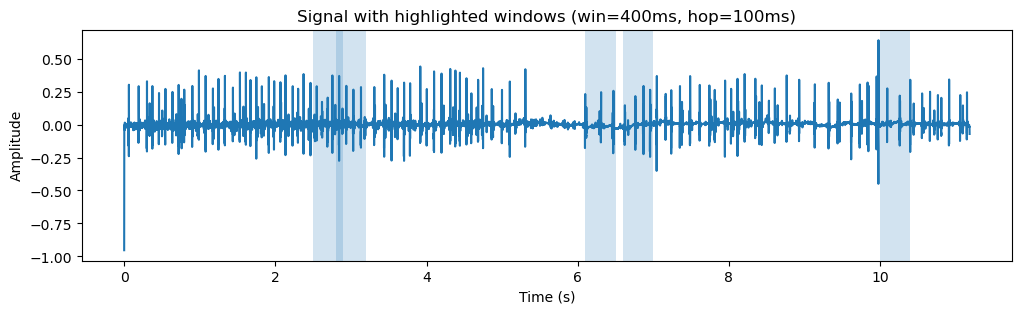

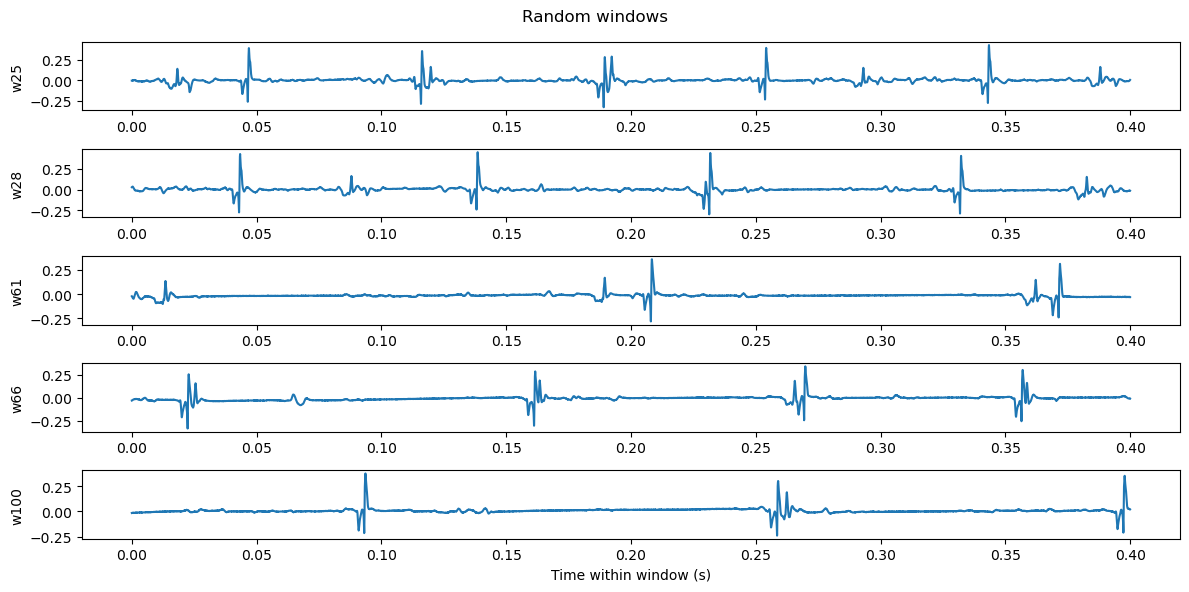

In [10]:
import random

win_ms, hop_ms = 400, 100
win = ms_to_samples(win_ms, fs)
hop = ms_to_samples(hop_ms, fs)

W = make_windows_1d(x, win, hop)
print("W shape:", W.shape)  # (n_windows, win)

# Choose a few random window indices
idxs = sorted(random.sample(range(W.shape[0]), k=min(5, W.shape[0])))

# Plot the full signal (downsampled for speed) + highlight window positions
plt.figure(figsize=(12, 3))
ds = max(1, len(x)//20000)
plt.plot(np.arange(0, len(x), ds)/fs, x[::ds])
for i in idxs:
    start = i * hop
    end = start + win
    plt.axvspan(start/fs, end/fs, alpha=0.2)
plt.title(f"Signal with highlighted windows (win={win_ms}ms, hop={hop_ms}ms)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Plot the selected windows
plt.figure(figsize=(12, 6))
for j, i in enumerate(idxs, 1):
    plt.subplot(len(idxs), 1, j)
    t = np.arange(win) / fs
    plt.plot(t, W[i])
    plt.ylabel(f"w{i}")
plt.xlabel("Time within window (s)")
plt.suptitle("Random windows")
plt.tight_layout()
plt.show()